В цьому ноутбуці наглядно демонструєтся робота бектест алгоритму на всій доступній історії аткиву

In [1]:
import os
os.chdir("..")

In [2]:
import pandas as pd
import numpy as np
import random
import yaml

from app import BacktestDCA
from ploter import ploter

/Users/aleksejkitajskij/Desktop/rebalance/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# stocks

In [3]:
df_stocks = pd.read_csv("data/test_crypto.csv", index_col=0, parse_dates=True)
df_stocks.dropna(how='all', inplace=True, axis=1)
df_stocks.dropna(how='all', inplace=True, axis=0)
df_stocks

,BTC,ETH,XRP,USDT,BCH,LTC,EOS,BNB,BSV,XLM,...,VET,BAT,OMG,SNX,COMP,YFI,UMA,ZRX,ICX,QTUM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-13,10214.379883,268.099243,0.326706,0.998579,474.317993,80.403427,5.341575,25.440100,359.041138,0.082655,...,0.008026,0.295389,1.280141,0.932967,NaN,NaN,NaN,0.320865,0.394342,2.842507
2020-02-14,10312.116211,284.217499,0.334822,1.000114,491.160645,82.990349,5.361947,26.296959,360.390015,0.085796,...,0.008323,0.311020,1.370907,0.992797,NaN,NaN,NaN,0.345264,0.400229,3.015611
2020-02-15,9889.424805,264.728577,0.306236,0.999128,437.664948,76.513245,4.743118,24.149651,310.077820,0.079246,...,0.007440,0.280342,1.289413,0.949770,NaN,NaN,NaN,0.317226,0.360399,2.677241
2020-02-16,9934.433594,259.894714,0.295034,0.999272,415.940643,75.152588,4.412250,23.466389,285.867523,0.075079,...,0.007133,0.264260,1.190897,0.945258,NaN,NaN,NaN,0.299002,0.348740,2.511193
2020-02-17,9690.142578,266.363434,0.286572,0.998474,409.344574,73.251305,4.346360,23.551378,309.441620,0.071851,...,0.006756,0.266563,1.169630,1.011205,NaN,NaN,NaN,0.291352,0.344687,2.499368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,68233.312500,2104.708252,1.340259,0.999024,466.334564,53.917908,0.075516,617.049194,13.852106,0.167265,...,0.006763,0.096228,0.054769,0.287147,NaN,2486.911377,0.409303,0.103136,0.034007,0.887649
2026-04-01,68078.554688,2138.737061,1.347766,0.999800,454.311554,53.805855,0.078632,610.622986,14.003111,0.169253,...,0.006885,0.099325,0.055448,0.281543,NaN,2456.119385,0.409600,0.104537,0.035458,0.930321
2026-04-02,66888.570312,2056.852539,1.318691,0.999892,444.056213,52.260174,0.076542,583.136841,14.614312,0.163015,...,0.006740,0.094341,0.053399,0.278585,NaN,2413.258057,0.387646,0.102121,0.035270,0.879604


In [4]:
stock = 'BCH'
prices = df_stocks[stock]

In [5]:
strategy = {
    "buy_amount": 10,
}

11:53:43 - cmdstanpy - INFO - Chain [1] start processing
11:53:43 - cmdstanpy - INFO - Chain [1] done processing


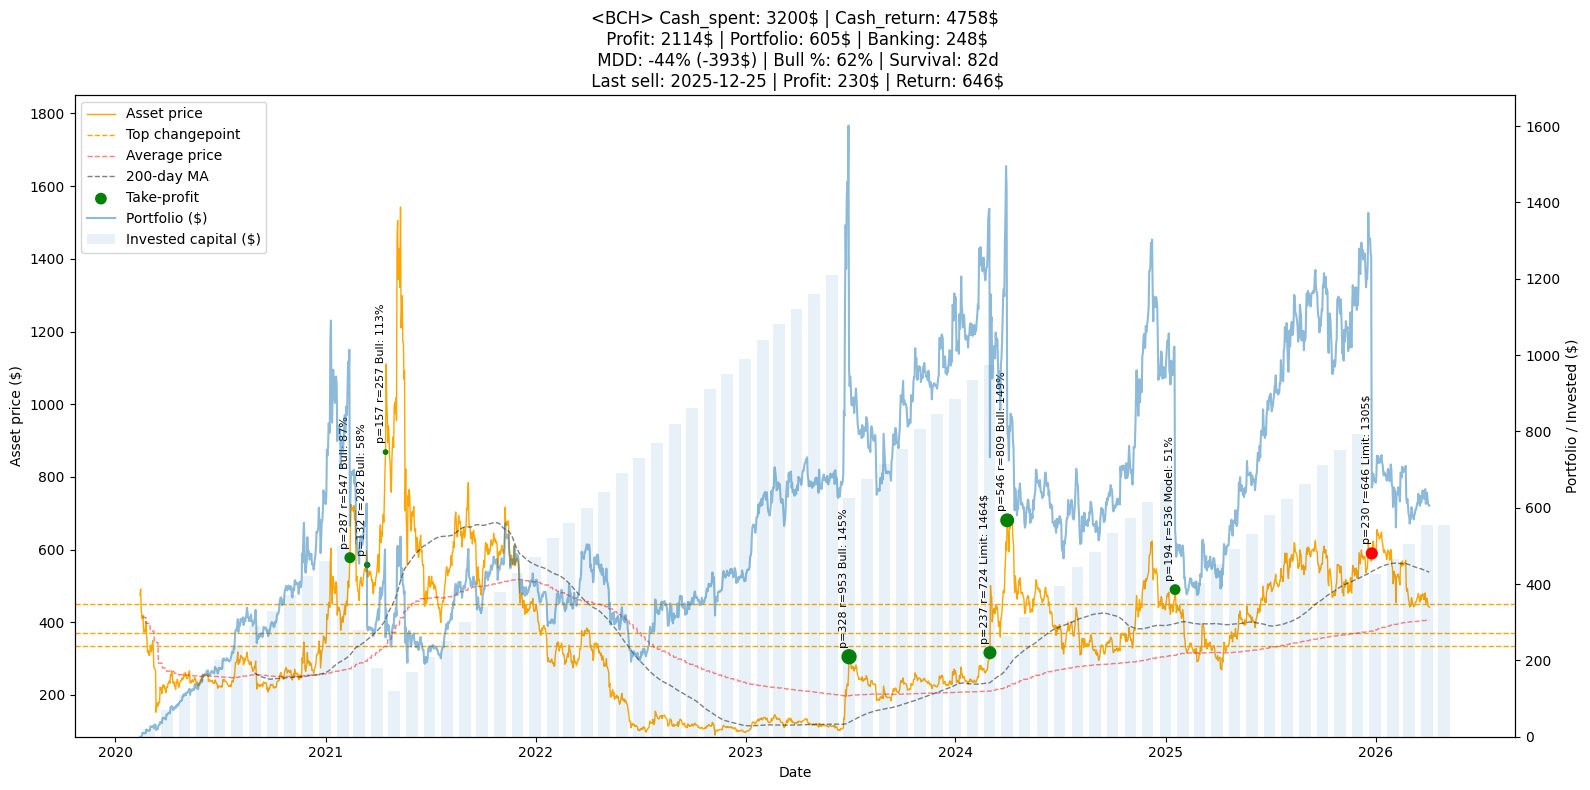

In [6]:
bt = BacktestDCA(
target=stock,
prices=prices,
strategy=strategy
)
result, metrics = bt.run()
ploter(metrics=metrics, history=result)

In [7]:
metrics

{'Target': 'BCH',
 'Cash_spent': 3200,
 'Cash_return': 4758,
 'Portfolio': 605,
 'Profit': 2114,
 'Bull_history': 62,
 'Num_take_profits': 8,
 'MDD': -44,
 'MDD_usd': -393,
 'Bank_profit': 248,
 'MA200_survival_days': 82.0}

In [8]:
result

,Price,Qty,Cost_basis,Cash_spent,Profit,Returns,Trigger_msg,Portfolio,Average_price
Date,,,,,,,,,
2020-02-13,474.317993,0.000000,0.0000,0.0,0.0,0.0,,0.000000,NaN
2020-02-14,491.160645,0.000000,0.0000,0.0,0.0,0.0,,0.000000,NaN
2020-02-15,437.664948,0.000000,0.0000,0.0,0.0,0.0,,0.000000,NaN
2020-02-16,415.940643,0.000000,0.0000,0.0,0.0,0.0,,0.000000,NaN
2020-02-17,409.344574,0.024185,10.0000,10.0,0.0,0.0,,9.900000,413.479368
...,...,...,...,...,...,...,...,...,...
2026-03-31,466.334564,1.371042,555.9375,3200.0,0.0,0.0,,639.364446,405.485280
2026-04-01,454.311554,1.371042,555.9375,3200.0,0.0,0.0,,622.880390,405.485280
2026-04-02,444.056213,1.371042,555.9375,3200.0,0.0,0.0,,608.819883,405.485280
